### Tasks

* 1. Write Python functions for the sigmoid, tanh, and ReLU activation functions that take a single float as input and return the output value.

In [6]:
import numpy as np

In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [2]:
def tanh(x):
    return np.tanh(x)

In [3]:
def relu(x):
    return np.maximum(0, x)

* 2. Use matplotlib to plot the graphs of sigmoid, tanh, and ReLU functions on the same figure for input values ranging from -10 to 10.<br><br><em><strong>Hint:</strong> Use numpy to generate input values and label each curve clearly.</em>

In [9]:
import matplotlib.pyplot as plt

In [11]:
x_values = np.linspace(-10, 10, 200)

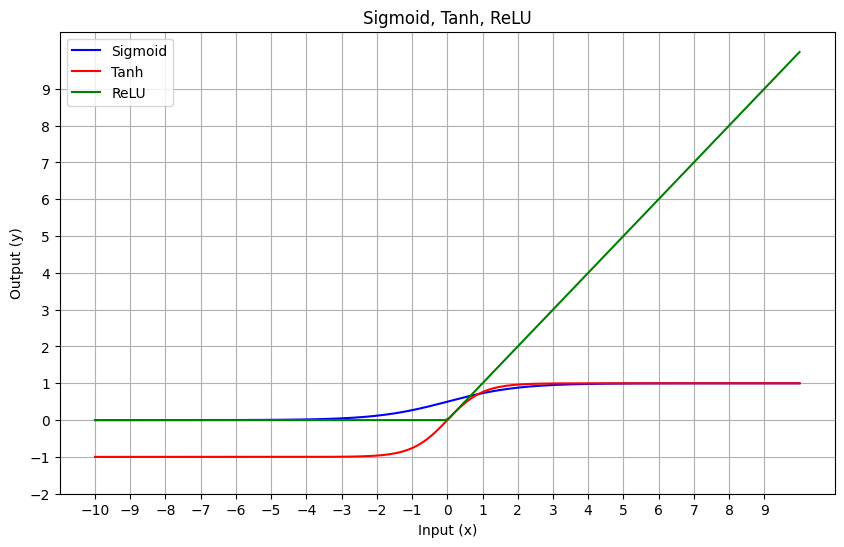

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(x_values, sigmoid(x_values), label="Sigmoid", color="blue")
plt.plot(x_values, tanh(x_values), label="Tanh", color="red")
plt.plot(x_values, relu(x_values), label="ReLU", color="green")

plt.xticks(range(-10,10))
plt.yticks(range(-2,10))
plt.title("Sigmoid, Tanh, ReLU")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.legend()
plt.grid(True)
plt.show()

* 3. Simulate the vanishing gradient problem by calculating and printing the derivative of the sigmoid function for input values between -10 and 10. Observe and explain where the gradient becomes very small.

In [13]:
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [14]:
test_inputs = np.array([-10, -5, -2, 0, 2, 5, 10])

In [16]:
for val in test_inputs:
    grad = sigmoid_derivative(val)
    print(f"Input: {val:3} and Gradient: {grad}")

Input: -10 and Gradient: 4.5395807735951673e-05
Input:  -5 and Gradient: 0.006648056670790155
Input:  -2 and Gradient: 0.1049935854035065
Input:   0 and Gradient: 0.25
Input:   2 and Gradient: 0.10499358540350662
Input:   5 and Gradient: 0.006648056670790033
Input:  10 and Gradient: 4.5395807735907655e-05


#### Explanation:
The gradient becomes very small (saturates near 0.0000) when the input is strongly. negative (e.g., -10) or strongly positive (e.g., 10). Because the sigmoid curve flattens out. at its extremes, its slope approaches zero. In deep networks, multiplying these tiny gradients. together during backpropagation causes updates to vanish, halting training.

* 4. Create a function that demonstrates the 'dying ReLU' problem by passing an array of negative values through the ReLU function and showing the output.<br><br><em><strong>Hint:</strong> Print both the input and output arrays to highlight the effect.</em>

In [22]:
def demonstrate_dying_relu():
    negative_inputs = np.array([-1.5, -5.0, -0.1, -12.4, -0.01])
    outputs = relu(negative_inputs)

    print(f"Input Array (Negative Values): {negative_inputs}")
    print(f"ReLU Output Array:              {outputs}")

demonstrate_dying_relu()

Input Array (Negative Values): [-1.50e+00 -5.00e+00 -1.00e-01 -1.24e+01 -1.00e-02]
ReLU Output Array:              [0. 0. 0. 0. 0.]


#### Explanation:
Because ReLU outputs exactly 0 for any negative number, its gradient is also 0 here. If a neuron gets stuck in a state where it only receives negative inputs, it outputs. zero perpetually and its weights will never update again — the neuron is effectively 'dead'.

* 5. Pick any activation function (sigmoid, tanh, or ReLU) and modify its Python implementation to add a parameter that scales the input (e.g., f(x) = sigmoid(a*x) where 'a' is a new parameter). Plot and compare the original and modified activation functions using matplotlib.

In [23]:
def modified_sigmoid(x, a):
    return 1 / (1 + np.exp(-(a * x)))

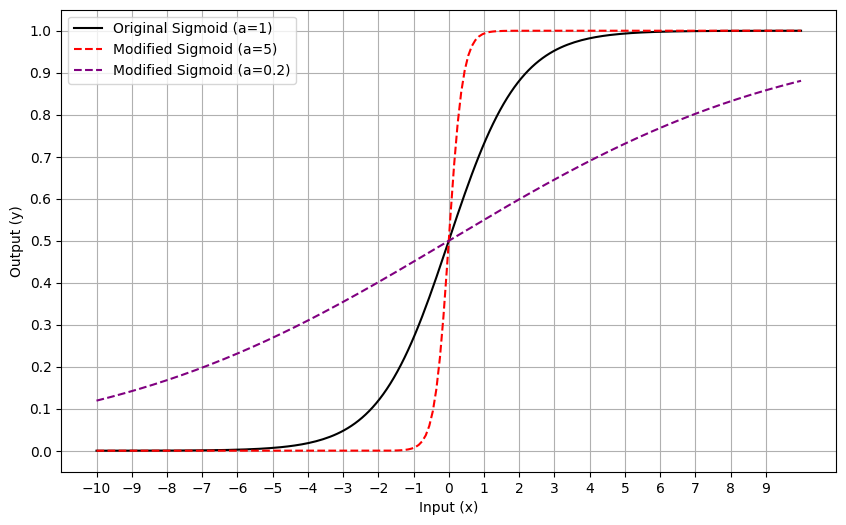

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(x_values, sigmoid(x_values), label="Original Sigmoid (a=1)", color="black")
plt.plot(x_values, modified_sigmoid(x_values, a=5), label="Modified Sigmoid (a=5)", color="red", linestyle="--")
plt.plot(x_values, modified_sigmoid(x_values, a=0.2), label="Modified Sigmoid (a=0.2)", color="purple", linestyle="--")

plt.xticks(range(-10,10))
plt.yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
# plt.yticks()
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.legend()
plt.grid(True)
plt.show()